In [18]:
import os
import math
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, cohen_kappa_score, precision_score, recall_score
from sklearn.model_selection import KFold, train_test_split

In [19]:
LABEL_DICT = {
    "Sleep stage W": 0,
    "Sleep stage 1": 1,
    "Sleep stage 2": 2,
    "Sleep stage 3": 3,
    "Sleep stage 4": 3, # Usually N3 and N4 are merged
    "Sleep stage R": 4,
}
CLASS_LABELS = {
    "W": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3,
    "R": 4
}

In [20]:
def plot_folds_results(y_true, y_pred, histories):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 1. Plot Training/Validation Curves (Averaged over folds)
    plt.figure(figsize=(12, 5))
    
    # Average the losses across all folds for a cleaner plot
    avg_train_loss = np.mean([fh['train_loss'] for fh in histories], axis=0)
    avg_val_loss = np.mean([fh['val_loss'] for fh in histories], axis=0)
    
    score_reports = {
        "accuracy": [np.mean(fh['val_acc']) for fh in histories],
        "f1": [np.mean(fh['val_f1']) for fh in histories],
        "kappa": [np.mean(fh['val_kappa']) for fh in histories],
    }
    
    plt.subplot(1, 2, 1)
    plt.plot(avg_train_loss, label='Avg Train Loss')
    plt.plot(avg_val_loss, label='Avg Val Loss')
    plt.title('Cross-Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # 2. Confusion Matrix Plot
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_true, y_pred)
    # Normalize CM to see percentages
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_LABELS.keys(), 
                yticklabels=CLASS_LABELS.keys())
    plt.title('Aggregated Normalized Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.savefig('results/cv_performance_results.png')
    plt.show()

    # 3. Print Comprehensive Scores
    print("\n" + "="*30)
    print("FINAL 10-FOLD CV RESULTS")
    print("="*30)
    print(classification_report(y_true, y_pred, target_names=list(CLASS_LABELS.keys())))
    
    # 4. Report fold scores
    report_df = pd.DataFrame(score_reports, index=[f"fold {i + 1}" for i in range(len(histories))])
    print(f"\n\nFolds Score Report Summary")
    print(report_df)

In [21]:
def plot_oneLoop_results(y_true, y_pred, histories):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 1. Plot Training/Validation Curves
    plt.figure(figsize=(12, 5))
    
    # Average the losses for a cleaner plot
    avg_train_loss = np.mean(histories['train_loss'], axis=0)
    avg_val_loss = np.mean(histories['val_loss'], axis=0)
    
    score_reports = {
        "accuracy": np.mean(histories['val_acc'], axis=0),
        "f1": np.mean(histories['val_f1'], axis=0),
        "kappa": np.mean(histories['val_kappa'], axis=0),
    }
    
    plt.subplot(1, 2, 1)
    plt.plot(avg_train_loss, label='Avg Train Loss')
    plt.plot(avg_val_loss, label='Avg Val Loss')
    plt.title('Cross-Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # 2. Confusion Matrix Plot
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_true, y_pred)
    # Normalize CM to see percentages
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_LABELS.keys(), 
                yticklabels=CLASS_LABELS.keys())
    plt.title('Aggregated Normalized Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.savefig('results/cv_performance_results.png')
    plt.show()

    # 3. Print Comprehensive Scores
    print("\n" + "="*30)
    print("FINAL ONE LOOP RESULTS")
    print("="*30)
    print(classification_report(y_true, y_pred, target_names=list(CLASS_LABELS.keys())))
    
    # 4. Report scores
    print(f"Final Scores Report:\nAccuracy: {score_reports['accuracy']} | F1: {score_reports['f1']} | Kappa: {score_reports['kappa']}")

In [31]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        
        # Create a matrix of [max_len, d_model] filled with 0s
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # Calculate the division term (the denominator in the formula)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # Fill even indices with sin, odd with cos
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Add a batch dimension: [1, max_len, d_model]
        pe = pe.unsqueeze(0)
        
        # Register as buffer (it's not a parameter, but stays with the model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        # Simply add the precomputed encoding to the input
        x = x + self.pe[:, :x.size(1), :]
        return x

class SleepMultiBranchModel(nn.Module):
    def __init__(self, num_classes=5, window_size=5, embed_dim=256, num_heads=8, dropout=0.3):
        super(SleepMultiBranchModel, self).__init__()
        self.embed_dim = embed_dim
        self.window_size = window_size
        self.num_classes = num_classes
        
        # 1. Define the feature extractors
        self.fe400 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=400),
            nn.BatchNorm1d(num_features=16),
            nn.ReLU(),
            nn.MaxPool1d(8, 8),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fe50 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=8, kernel_size=50, padding=25),
            nn.BatchNorm1d(num_features=8),
            nn.ReLU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(in_channels=8, out_channels=16, kernel_size=25),
            nn.BatchNorm1d(num_features=16),
            nn.ReLU(),
            nn.MaxPool1d(2, 2),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=10),
            nn.BatchNorm1d(num_features=32),
            nn.ReLU(),
            nn.MaxPool1d(2, 2),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # (K=100): The model is "zoomed out." It can see the entire cycle of a Delta wave (0.5–4 Hz),
        # which is the hallmark of N3 (Deep Sleep).
        self.fe100 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=8, kernel_size=100, padding=50), # Maintains length
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(in_channels=8, out_channels=16, kernel_size=50, padding=25), # Smaller kernel here
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2, 2),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # (K=25): The model is "zoomed in." It can easily see the sharp peaks and fast rhythms of Beta waves 
        # (13–30 Hz) and Alpha waves (8–13 Hz). These are crucial for detecting Wakefulness and REM sleep.
        # At layer 2 (K=16), it sees now represents 4 points from the original signal. So, $16 \times 4 = 64$ points, or 0.64s. 
        # This is the perfect "sweet spot" for Sleep Spindles (which usually last 0.5s to 1.5s).
        self.fe25 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=8, kernel_size=25, padding=13),
            nn.BatchNorm1d(num_features=8),
            nn.ReLU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(in_channels=8, out_channels=16, kernel_size=16, padding=8),
            nn.BatchNorm1d(num_features=16),
            nn.ReLU(),
            nn.MaxPool1d(2, 2),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=8, padding=4),
            nn.BatchNorm1d(num_features=32),
            nn.ReLU(),
            nn.MaxPool1d(2, 2),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=4, padding=2),
            nn.BatchNorm1d(num_features=64),
            nn.ReLU(),
            nn.MaxPool1d(2, 2),
            nn.AdaptiveAvgPool1d(1)
        )
        
        self.fe5 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=8, kernel_size=5, padding=2),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(in_channels=8, out_channels=16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2, 2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2, 2),
            nn.AdaptiveAvgPool1d(1)
        )
        
        self.fe64 = nn.Sequential(
            # Layer 1: Capture broad waveforms (0.5s window)
            nn.Conv1d(1, 64, kernel_size=50, stride=1, padding=25),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4, 4),
            nn.Dropout(0.2), # Prevent overfitting early
            # Layer 2: Extract patterns (1.0s effective window)
            nn.Conv1d(64, 128, kernel_size=16, padding=8),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(4, 4),
            # Layer 3: Deep features (4.0s effective window)
            nn.Conv1d(128, 256, kernel_size=8, padding=4),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(4, 4),
            # Layer 4: Global context
            nn.Conv1d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # 2. Multi-Head Attention Layer
        self.pos_embedding = SinusoidalPositionalEncoding(self.embed_dim)
        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        self.layernorm = nn.LayerNorm(embed_dim)
        
        # 3. Classifier
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # x shape: (batch, win_size, channels, time)
        B, W, C, T = x.shape
        
        # Extract features for each epoch
        x = x.view(B * W, C, T)
        
        fe400_out = self.fe400(x)
        fe50_out = self.fe50(x)
        fe100_out = self.fe100(x)
        fe25_out = self.fe25(x)
        fe5_out = self.fe5(x)
        
        x = torch.concat([fe400_out, fe50_out, fe100_out, fe25_out, fe5_out], dim=1)
        
        # Reshape to (Batch, Window, Embedding)
        x = x.view(B, W, self.embed_dim)
        
        # Postitional Embedding
        x = self.pos_embedding(x)
        
        # Self-Attention
        # attn_output: (Batch, Window, Embedding)
        attn_output, _ = self.attention(x, x, x)
        x = self.layernorm(x + attn_output)  # Residual connection
        
        # Focus on the middle epoch (index 2 for window size 5)
        future_context = 2
        target_idx = W - (future_context + 1)
        mid_epoch_features = x[:, target_idx, :]
        
        return self.classifier(mid_epoch_features)

In [24]:
class SleepWindowDataset(Dataset):
    def __init__(self, file_paths, window_size=5, future_context=2, trim_margin_min=30 ):
        """
        window_size: must be odd (e.g., 5, 9, 21)
        """
        assert window_size % 2 != 0, "Window size must be an odd number."
        self.window_size = window_size
        self.future_context = future_context
        self.current_idx = window_size - future_context - 1
        self.past_context = self.current_idx
        
        self.features = []
        self.labels = []
        
        margin = (trim_margin_min * 60) // 30
        
        for path in file_paths:
            with np.load(path) as data:
                x, y = data['x'], data['y']
                
                # 1. Trimming based on sleep activity
                sleep_idx = np.where(y != 0)[0]
                if len(sleep_idx) == 0: continue
                
                start = max(0, sleep_idx[0] - margin)
                end = min(len(y), sleep_idx[-1] + margin + 1)
                x = x[start:end]
                y = y[start:end]
                
                # 2. Subject-level Z-score Normalization
                x = (x - np.mean(x)) / (np.std(x) + 1e-8)
                
                # 3. Sliding Centered Window
                # We start from half_win and end at len - half_win
                for i in range(self.past_context, len(x) - self.future_context):
                    window = x[i - self.past_context : i + self.future_context + 1]
                    self.features.append(window)
                    self.labels.append(y[i])
                    
                self.features.append(window)
                self.labels.append(y[i]) # Label of the middle epoch

        # Stack into tensors
        self.X = torch.from_numpy(np.array(self.features)).float()
        self.Y = torch.from_numpy(np.array(self.labels)).long()

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [25]:
class Trainer:
    def __init__(self, model, device, fold_idx=None):
        self.model = model.to(device)
        self.device = device
        self.fold_idx = fold_idx if fold_idx else 0
        self.best_val_loss = float('inf')
        self.history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    def train_epoch(self, loader, optimizer, criterion):
        self.model.train()
        total_loss = 0
        for x, y in loader:
            x, y = x.to(self.device), y.to(self.device)
            optimizer.zero_grad()
            out = self.model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def validate(self, loader, criterion):
        self.model.eval()
        total_loss = 0
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for x, y in loader:
                x, y = x.to(self.device), y.to(self.device)
                out = self.model(x)
                loss = criterion(out, y)
                total_loss += loss.item()
                preds = out.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
                
        avg_loss = total_loss / len(loader)
        scores = {
            "accuracy": accuracy_score(all_labels, all_preds),
            "f1": f1_score(all_labels, all_preds, average='macro'),
            "precision": precision_score(all_labels, all_preds, average='macro'),
            "recall": recall_score(all_labels, all_preds, average='macro'),
            "kappa": cohen_kappa_score(all_labels, all_preds)
        }
        return avg_loss, scores, all_preds, all_labels

    def save_checkpoint(self, val_loss):
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            torch.save(self.model.state_dict(), f"checkpoints/best_model_fold_{self.fold_idx}.pt")

In [26]:
data_path = "/home/kasra/courses/2026-edge-computing/project/dataset/sleepEDF/processed/SC"
all_files = np.array(sorted(glob.glob(os.path.join(data_path, "*.npz"))))

tr, te = train_test_split(all_files, test_size=30, random_state=42, shuffle=True)
ttrain_ds = SleepWindowDataset(tr, window_size=5)
tval_ds = SleepWindowDataset(te, window_size=5)
train_loader = DataLoader(ttrain_ds, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(tval_ds, batch_size=64, shuffle=False)

# Compute class weights for this fold to handle imbalance
# tcounts = np.bincount(ttrain_ds.Y.numpy())

In [ ]:
# DEBUGG

x, y = next(iter(train_loader))
x.shape
B, W, C, T = x.shape
x = x.view(B * W, C, T)
x.shape

torch.Size([64, 5, 1, 3000])

In [ ]:
def run_loop(window_size=5):
    data_path = "/home/kasra/courses/2026-edge-computing/project/dataset/sleepEDF/processed/SC"
    all_files = np.array(sorted(glob.glob(os.path.join(data_path, "*.npz"))))
    
    # Define 10-fold cross-validation on files (subjects)
    train_files, val_files = train_test_split(all_files, test_size=30, random_state=42, shuffle=True)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("\nDevice: ", device)
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_kappa': []}
    best_preds = None
    best_labels = None

    print(f"\n{'='*20} Training {'='*20}")
    
    # 1. Initialize Datasets (Subject-wise split)
    train_ds = SleepWindowDataset(train_files, window_size=window_size, future_context=2)
    val_ds = SleepWindowDataset(val_files, window_size=window_size, future_context=2)
    
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

    # 2. Setup Model, Loss (Weighted), and Optimizer
    model = SleepMultiBranchModel(num_classes=5).to(device)
    
    # Compute class weights on train data to handle imbalance
    counts = np.bincount(train_ds.Y.numpy())
    weights = 1.0 / torch.tensor(counts, dtype=torch.float32).to(device)
    # Assign weights to classes based on the proportion of the data for that particular class
    criterion = torch.nn.CrossEntropyLoss(weight=weights)
    num_epochs = 20
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    
    # 3. Training/Validation Loop
    trainer = Trainer(model, device) # Uses the Trainer class from previous step

    for epoch in range(num_epochs):  # Adjust epochs as needed
        t_loss = trainer.train_epoch(train_loader, optimizer, criterion)
        v_loss, v_scores, preds, labels = trainer.validate(val_loader, criterion)
        scheduler.step()
        
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_scores["accuracy"])
        history['val_f1'].append(v_scores["f1"])
        history['val_kappa'].append(v_scores["kappa"])
        
        # Checkpoint: Save if best val_loss
        if v_loss < trainer.best_val_loss:
            trainer.best_val_loss = v_loss
            torch.save(model.state_dict(), f"checkpoints/best_model_fold.pt")
            best_preds = preds
            best_labels = labels
        
        if epoch % 5 == 0:
            print(f"Epoch {epoch:02d} | T-Loss: {t_loss:.4f} | V-Loss: {v_loss:.4f} | V-Acc: {v_scores["accuracy"]:.2f} | V-kappa: {v_scores["kappa"]:.2f}")

    # 4. Final Analysis and Plotting5
    plot_oneLoop_results(best_labels, best_preds, history)

In [33]:
def run_kfold(window_size=5):
    data_path = "/home/kasra/courses/2026-edge-computing/project/dataset/sleepEDF/processed/SC"
    all_files = np.array(sorted(glob.glob(os.path.join(data_path, "*.npz"))))
    
    # Define 10-fold cross-validation on files (subjects)
    n_folds = 5
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("\nDevice: ", device)
    
    # Storage for overall metrics
    all_fold_preds = []
    all_fold_labels = []
    fold_histories = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(all_files)):
        print(f"\n{'='*20} Fold {fold+1}/{n_folds} {'='*20}")
        
        # 1. Initialize Datasets (Subject-wise split)
        train_ds = SleepWindowDataset(all_files[train_idx], window_size=window_size)
        val_ds = SleepWindowDataset(all_files[val_idx], window_size=window_size)
        
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

        # 2. Setup Model, Loss (Weighted), and Optimizer
        model = SleepMultiBranchModel(num_classes=5).to(device)
        
        # Compute class weights for this fold to handle imbalance
        counts = np.bincount(train_ds.Y.numpy())
        weights = 1.0 / torch.tensor(counts, dtype=torch.float32).to(device)
        criterion = torch.nn.CrossEntropyLoss(weight=weights)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        
        # 3. Training/Validation Loop
        trainer = Trainer(model, device, fold) # Uses the Trainer class from previous step
        fold_history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_kappa': []}
        best_fold_preds = None
        best_fold_labels = None

        for epoch in range(20):  # Adjust epochs as needed
            t_loss = trainer.train_epoch(train_loader, optimizer, criterion)
            v_loss, v_scores, preds, labels = trainer.validate(val_loader, criterion)
            scheduler.step(v_loss)
            
            fold_history['train_loss'].append(t_loss)
            fold_history['val_loss'].append(v_loss)
            fold_history['val_acc'].append(v_scores["accuracy"])
            fold_history['val_f1'].append(v_scores["f1"])
            fold_history['val_kappa'].append(v_scores["kappa"])
            
            # Checkpoint: Save if best val_loss
            if v_loss < trainer.best_val_loss:
                trainer.best_val_loss = v_loss
                torch.save(model.state_dict(), f"checkpoints/best_model_fold_{fold}.pt")
                best_fold_preds = preds
                best_fold_labels = labels
            
            if epoch % 5 == 0:
                print(f"Epoch {epoch:02d} | T-Loss: {t_loss:.4f} | V-Loss: {v_loss:.4f} | V-Acc: {v_scores["accuracy"]:.2f} | V-kappa: {v_scores["kappa"]:.2f}")

        # Store results for this fold
        all_fold_preds.extend(best_fold_preds)
        all_fold_labels.extend(best_fold_labels)
        fold_histories.append(fold_history)

    # 4. Final Analysis and Plotting5
    plot_folds_results(all_fold_labels, all_fold_preds, fold_histories)


Device:  cuda

==================== Training ====================
Epoch 00 | T-Loss: 0.6592 | V-Loss: 0.5326 | V-Acc: 0.74 | V-kappa: 0.67
Epoch 05 | T-Loss: 0.4762 | V-Loss: 0.4632 | V-Acc: 0.81 | V-kappa: 0.74
Epoch 10 | T-Loss: 0.3685 | V-Loss: 0.4984 | V-Acc: 0.79 | V-kappa: 0.73
Epoch 15 | T-Loss: 0.2861 | V-Loss: 0.6119 | V-Acc: 0.80 | V-kappa: 0.73


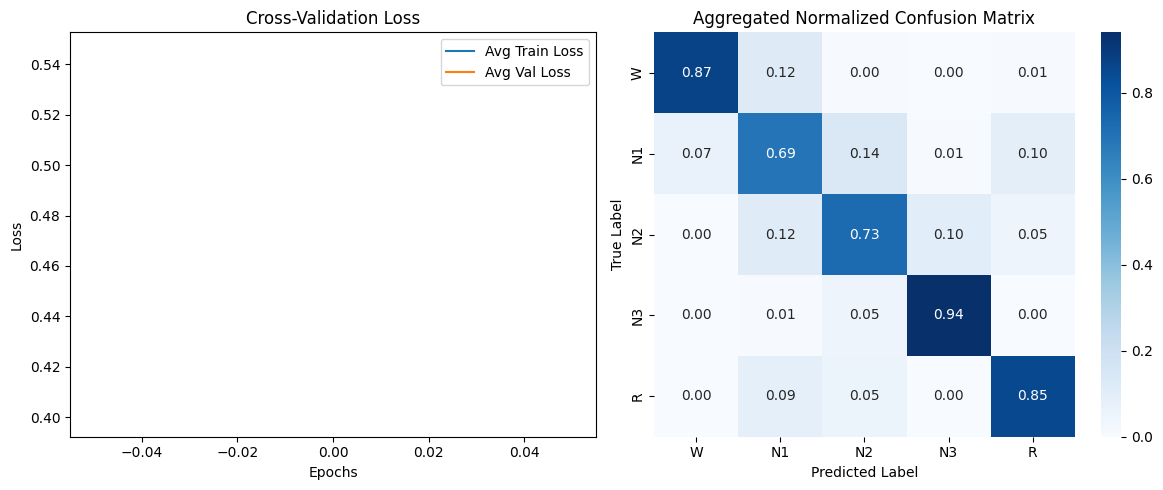


FINAL ONE LOOP RESULTS
              precision    recall  f1-score   support

           W       0.97      0.87      0.92     11386
          N1       0.44      0.69      0.54      3849
          N2       0.91      0.73      0.81     13118
          N3       0.67      0.94      0.79      3085
           R       0.80      0.85      0.83      5049

    accuracy                           0.81     36487
   macro avg       0.76      0.82      0.78     36487
weighted avg       0.84      0.81      0.81     36487

Final Scores Report:
Accuracy: 0.7935086469153397 | F1: 0.7653337453382372 | Kappa: 0.7290659704046772


In [34]:
if __name__ == "__main__":
    # This ensures that child workers don't execute run_kfold() again
    run_loop(window_size=9)

## DEBUG

In [ ]:
margin = (30 * 60) // 30
samples = []
labels = []
data_path = "/home/kasra/courses/2026-edge-computing/project/dataset/sleepEDF/processed/SC"
file_paths = np.array(glob.glob(os.path.join(data_path, "*.npz")))

for path in file_paths:
    with np.load(path) as data:
        x, y = data['x'], data['y']
        # Trimming logic
        sleep_idx = np.where(y != 0)[0]
        if len(sleep_idx) > 0:
            start, end = max(0, sleep_idx[0]-margin), min(len(y), sleep_idx[-1]+margin+1)
            x, y = x[start:end], y[start:end]
            
            # Normalize per subject (Z-score)
            x = (x - np.mean(x)) / (np.std(x) + 1e-8)
            
            samples.append(torch.from_numpy(x).float())
            labels.append(torch.from_numpy(y).long())

# Flatten for the DataLoader, but we kept them separate during loading
X = torch.cat(samples, dim=0)
Y = torch.cat(labels, dim=0)

In [ ]:
X.shape

torch.Size([195479, 1, 3000])